# Gap Control From Mock NHL Tracking Data

Gap control is a simple way to ask: when one team is near the puck, how close is the nearest defender? This notebook uses the mock CSV instead of hard-coded sample rows so the same workflow can grow when better data becomes available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

tracking = pd.read_csv('trackingData_v2.csv')

numeric_cols = ['Location.X', 'Location.Y', 'velocity_x', 'velocity_y', 'UTCTime']
for col in numeric_cols:
    tracking[col] = (
        tracking[col]
        .astype(str)
        .str.replace('−', '-', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

running = tracking[tracking['ClockState'] == 'ClockStateRunning'].copy()
players = running[running['entityType'] == 'player'].copy()
puck = running[running['entityType'] == 'puck'].copy()

print('Running timestamps:', sorted(running['timeStamp'].unique()))
print('Teams:', sorted(players['team'].dropna().unique()))
display(players.head())

Running timestamps: [np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Teams: ['A', 'B']


,timeStamp,entityId,entityType,team,player,Location.X,Location.Y,velocity_x,velocity_y,UTCTime,OnPlayingSurface,ClockState
1,1,1,player,A,Player1,-1.0000,1.0000,0.3000,-0.1000,1000,1,ClockStateRunning
2,1,2,player,A,Player2,2.0000,0.5000,-0.1000,0.0000,1000,1,ClockStateRunning
3,1,3,player,B,Player3,0.5000,-0.5000,0.0000,0.2000,1000,1,ClockStateRunning
4,1,4,player,B,Player4,6.0000,-1.5000,-0.2000,0.1000,1000,1,ClockStateRunning
5,1,5,player,A,Player5,4.5000,-2.0000,0.0000,0.0000,1000,1,ClockStateRunning


## Calculate Gap Control

For each running timestamp, the notebook identifies the player closest to the puck as the estimated puck carrier. Then it finds the closest opponent to that puck carrier. The distance between those two players is the gap.

In [2]:
def distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

gap_rows = []

for timestamp, frame_players in players.groupby('timeStamp'):
    puck_row = puck[puck['timeStamp'] == timestamp]
    if puck_row.empty:
        continue

    puck_x = puck_row.iloc[0]['Location.X']
    puck_y = puck_row.iloc[0]['Location.Y']

    frame_players = frame_players.copy()
    frame_players['distance_to_puck'] = distance(
        frame_players['Location.X'], frame_players['Location.Y'], puck_x, puck_y
    )

    carrier = frame_players.sort_values('distance_to_puck').iloc[0]
    opponents = frame_players[frame_players['team'] != carrier['team']].copy()
    opponents['gap_distance'] = distance(
        opponents['Location.X'], opponents['Location.Y'], carrier['Location.X'], carrier['Location.Y']
    )

    closest_opponent = opponents.sort_values('gap_distance').iloc[0]

    gap_rows.append({
        'timeStamp': timestamp,
        'puck_x': puck_x,
        'puck_y': puck_y,
        'carrier_team': carrier['team'],
        'carrier_player': carrier['player'],
        'carrier_distance_to_puck': carrier['distance_to_puck'],
        'closest_opponent': closest_opponent['player'],
        'opponent_team': closest_opponent['team'],
        'gap_distance': closest_opponent['gap_distance']
    })

gap_control_df = pd.DataFrame(gap_rows)
gap_control_df['pressure_label'] = pd.cut(
    gap_control_df['gap_distance'],
    bins=[-np.inf, 1.0, 2.0, np.inf],
    labels=['tight pressure', 'medium gap', 'loose gap']
)

display(gap_control_df)

,timeStamp,puck_x,puck_y,carrier_team,carrier_player,carrier_distance_to_puck,closest_opponent,opponent_team,gap_distance,pressure_label
0,1,0.5000,0.2000,B,Player3,0.7000,Player2,A,1.8028,medium gap
1,2,5.1000,-1.9000,B,Player6,0.3162,Player5,A,0.5000,tight pressure
2,3,3.0000,-0.5000,A,Player2,1.2649,Player3,B,1.8358,medium gap
3,5,-0.2000,0.3000,A,Player1,0.8485,Player3,B,2.4698,loose gap


## Gap Control Summary

These outputs are deliberately small: average gap by team, pressure counts, and simple descriptive stats.

In [3]:
gap_summary = gap_control_df['gap_distance'].describe().to_frame('gap_distance')
team_gap_summary = (
    gap_control_df.groupby('carrier_team', as_index=False)
    .agg(
        possessions_estimated=('timeStamp', 'count'),
        average_gap=('gap_distance', 'mean'),
        smallest_gap=('gap_distance', 'min'),
        largest_gap=('gap_distance', 'max')
    )
    .sort_values('average_gap')
)
pressure_counts = gap_control_df['pressure_label'].value_counts().rename_axis('pressure_label').reset_index(name='timestamps')

display(gap_summary)
display(team_gap_summary)
display(pressure_counts)

,gap_distance
count,4.0000
mean,1.6521
std,0.8271
min,0.5000
25%,1.4771
50%,1.8193
75%,1.9943
max,2.4698


,carrier_team,possessions_estimated,average_gap,smallest_gap,largest_gap
1,B,2,1.1514,0.5000,1.8028
0,A,2,2.1528,1.8358,2.4698


,pressure_label,timestamps
0,medium gap,2
1,tight pressure,1
2,loose gap,1


## Quick Visual Outputs

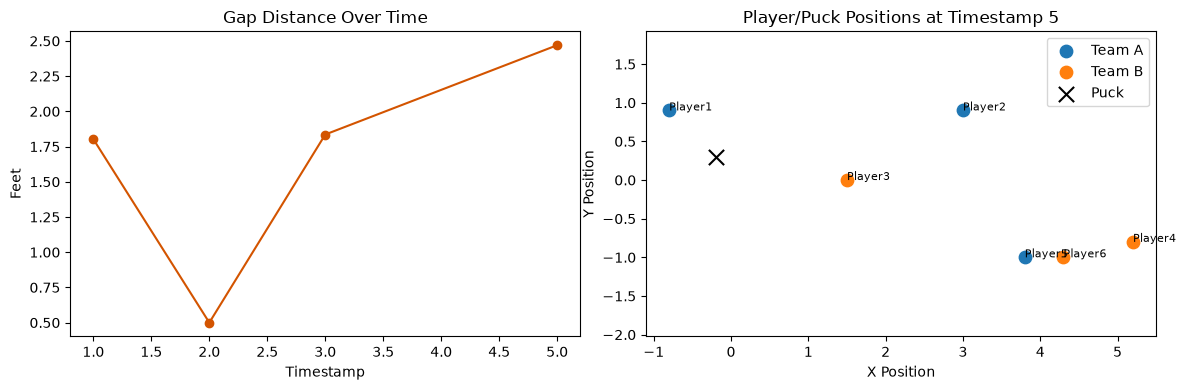

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gap_control_df.plot(
    x='timeStamp', y='gap_distance', marker='o', ax=axes[0], legend=False, color='#d35400'
)
axes[0].set_title('Gap Distance Over Time')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Feet')

latest_timestamp = gap_control_df['timeStamp'].max()
snapshot_players = players[players['timeStamp'] == latest_timestamp]
snapshot_puck = puck[puck['timeStamp'] == latest_timestamp].iloc[0]

for team, team_players in snapshot_players.groupby('team'):
    axes[1].scatter(team_players['Location.X'], team_players['Location.Y'], label=f'Team {team}', s=80)
    for _, row in team_players.iterrows():
        axes[1].annotate(row['player'], (row['Location.X'], row['Location.Y']), fontsize=8)

axes[1].scatter(snapshot_puck['Location.X'], snapshot_puck['Location.Y'], label='Puck', s=120, marker='x', color='black')
axes[1].set_title(f'Player/Puck Positions at Timestamp {latest_timestamp}')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()